# Accessing an APOGEE Spectrum with sdss-access

## Learning Goals
By the end of this tutorial, you will:
- Understand how to retrieve SDSS data with sdss-access
- Understand some of the structure of a fits file containing an APOGEE spectrum
- (Optionally) have a copy of the AllStarASPCAP file

## Introduction
The Apache Point Observatory Galactic Evolution Experiment (APOGEE) is an infrared spectroscopic survey using two spectrographs at the two SDSS V observatories, Apache Point Observatory (APO) and Las Campanas Observatory (LCO).

In this short tutorial we will briefly cover how to retrieve an object's sdss_id from the allStarASPCAP file, then show how to use the sdss-access tool to retreive the APOGEE spectrum of that star from the SDSS Science Archive Server (SAS).

## Imports
This tutorial requires two commonly used python packages, and an SDSS specific package
- _matplotlib_ for plotting
- _astropy_ for reading fits table
- _numpy_ for doing array math
- _sdss-access_ for accessing data on the SAS

Missing packages can be installed via `pip install matplotlib astropy numpy sdss-access` 

NOTE: You may want to set the `$SAS_BASE_DIR` environment variable before starting this notebook, other wise `$HOME/sas` will be created and used

In [1]:
import matplotlib.pyplot as plt
from astropy.table import Table
import numpy as np

from sdss_access import Access
access = Access(release="dr20")

import warnings

warnings.simplefilter("ignore")

Other tutorials give examples of using the astra allStar files to find ID numbers and other information. Since we're only interested in accessing spectra, we'll skip loading that large file for now and simply assume we know an sdss_id.

In [2]:
sdss_id = 94846885 

## sdss-access

sdss-access has extensive [documentation](https://sdss-access.readthedocs.io/en/latest/), but we should mention a few things. First if you are a member of the collaboration accessing proprietary data, you need to set up a [.netrc file](https://sdss-access.readthedocs.io/en/latest/auth.html). After that usage is the same for everyone.

You need specify the file species you need, in this case 'mwmStar', then a series of key word arguments that vary depending on the file species. A list of file species and their keyword arugments is [available](https://sdss-access.readthedocs.io/en/latest/paths.html).

The code block below showa an example of retreiving an sdss spectrum. First we construct the SAS file path with `access.full`, then we check to see if the file exists. If you are running this notebook on SciServer, or another system with a full copy of the SAS, or if you have downloaded this specific file before, we can skip downloading the data. Otherwise, `access.commit()` will retrieve the file and save it to your local SAS, `$SAS_BASE_DIR`, with the same structure as the SAS (so it will be many files deep). Note: it is important to skip the download step if the file already exists locally. Attempting to download a file that already exists can cause errors on some systems.

In [3]:
mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
if not access.exists('',full=mwmStar_filename):
    access.remote()
    access.add('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    access.set_stream()
    access.commit()
    mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)

access.exists('', full=mwmStar_filename)

True

## Load the spectrum

Now use `astropy.Table` load the data. HDU 3 contains the APO spectrum.

We then extract wavelength, flux, and ivar (inverse variance) to more convenient variables. Not we need the `[0]` entry. This is part of the file structure meant to be as similar as possible to other file species, which contain separat espectra for each visit. 

$ivar^{1/2}$ is a good representation of uncertainty in the flux

In [4]:
mwmStar = Table.read(mwmStar_filename, hdu=3)

obs_wl = mwmStar["wavelength"][0]
obs_flux = mwmStar["flux"][0]
obs_err = mwmStar["ivar"][0]**(-0.5)

In [5]:
mwmStar

spectrum_pk_id,release,filetype,v_astra,healpix,sdss_id,apred,obj,telescope,min_mjd,max_mjd,n_entries,n_visits,n_good_visits,n_good_rvs,snr,mean_fiber,std_fiber,spectrum_flags,v_rad,e_v_rad,std_v_rad,median_e_v_rad,doppler_teff,doppler_e_teff,doppler_logg,doppler_e_logg,doppler_fe_h,doppler_e_fe_h,doppler_rchi2,doppler_flags,xcorr_v_rad,xcorr_v_rel,xcorr_e_v_rel,ccfwhm,autofwhm,n_components,wavelength,flux,ivar,pixel_flags,continuum,nmf_rectified_model_flux,nmf_rchi2,nmf_flags
int64,bytes4,bytes6,bytes5,int32,int64,bytes4,bytes18,bytes6,int32,int32,int32,int32,int32,int32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,int32,float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32,int64
48535910,dr17,apStar,0.6.0,-1,94846885,dr17,2M03322788-0658199,apo25m,58018,58043,-1,-1,7,7,414.53464,44.082943,4.27618,10485760,28.610506,0.14462776,65.19732,0.14223586,--,--,--,--,--,--,--,0,--,--,--,--,--,-1,15100.802 .. 16999.807,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,-- .. --,50.799736,0


Now plot the spectrum, flux vs wavelength.

Note the mask.

Text(0, 0.5, 'flux')

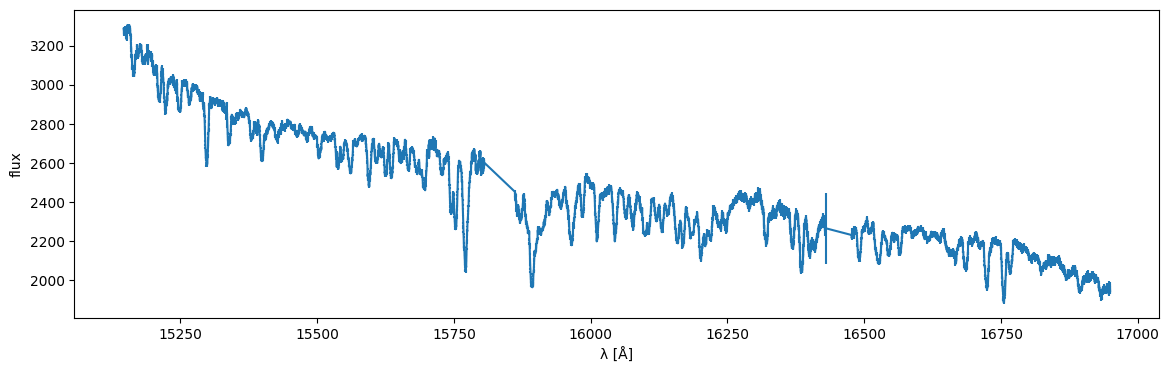

In [6]:
plt.figure(figsize=(14,4))

mask = obs_err < 0.1 * obs_flux

plt.errorbar(obs_wl[mask], obs_flux[mask], yerr=obs_err[mask])
plt.xlabel("λ [Å]")
plt.ylabel("flux")

A continuum fit is also provided, allowing us to continuum normalize the observed spectrum.

Text(0, 0.5, 'normlized flux')

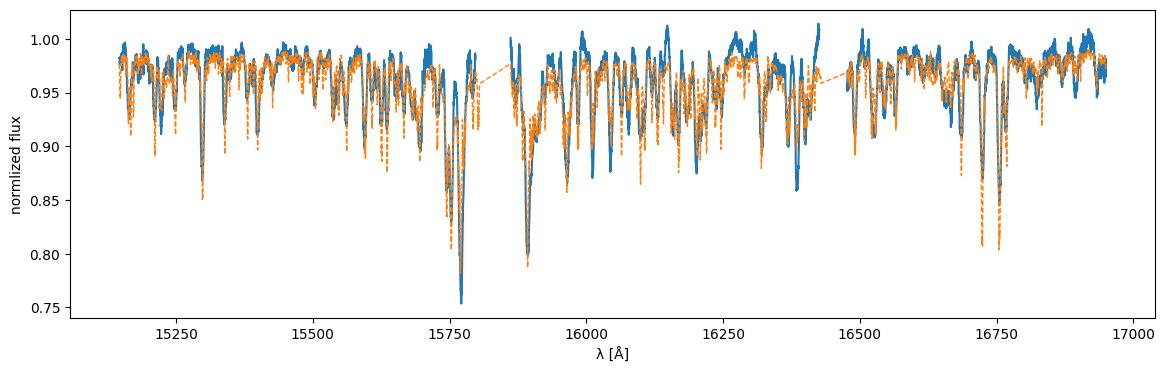

In [7]:
plt.figure(figsize=(14,4))

mask = obs_err < 0.1 * obs_flux

wl_plot = obs_wl[mask]
flux = obs_flux[mask]

continuum = mwmStar["continuum"][0][mask]

norm_flux = flux / continuum

model = mwmStar["nmf_rectified_model_flux"][0][mask]

plt.plot(wl_plot, norm_flux)
plt.plot(wl_plot, model, "--", linewidth=1)
plt.xlabel("λ [Å]")
plt.ylabel("normlized flux")

Adding the NMF model flux really shows just how much detail in the APOGEE spectra is being neglected by this high-level view. The code below splits the spectrum into 8 chunks so we can see individual lines, and the model fit. A few absorption line labels are added to guide the eye.

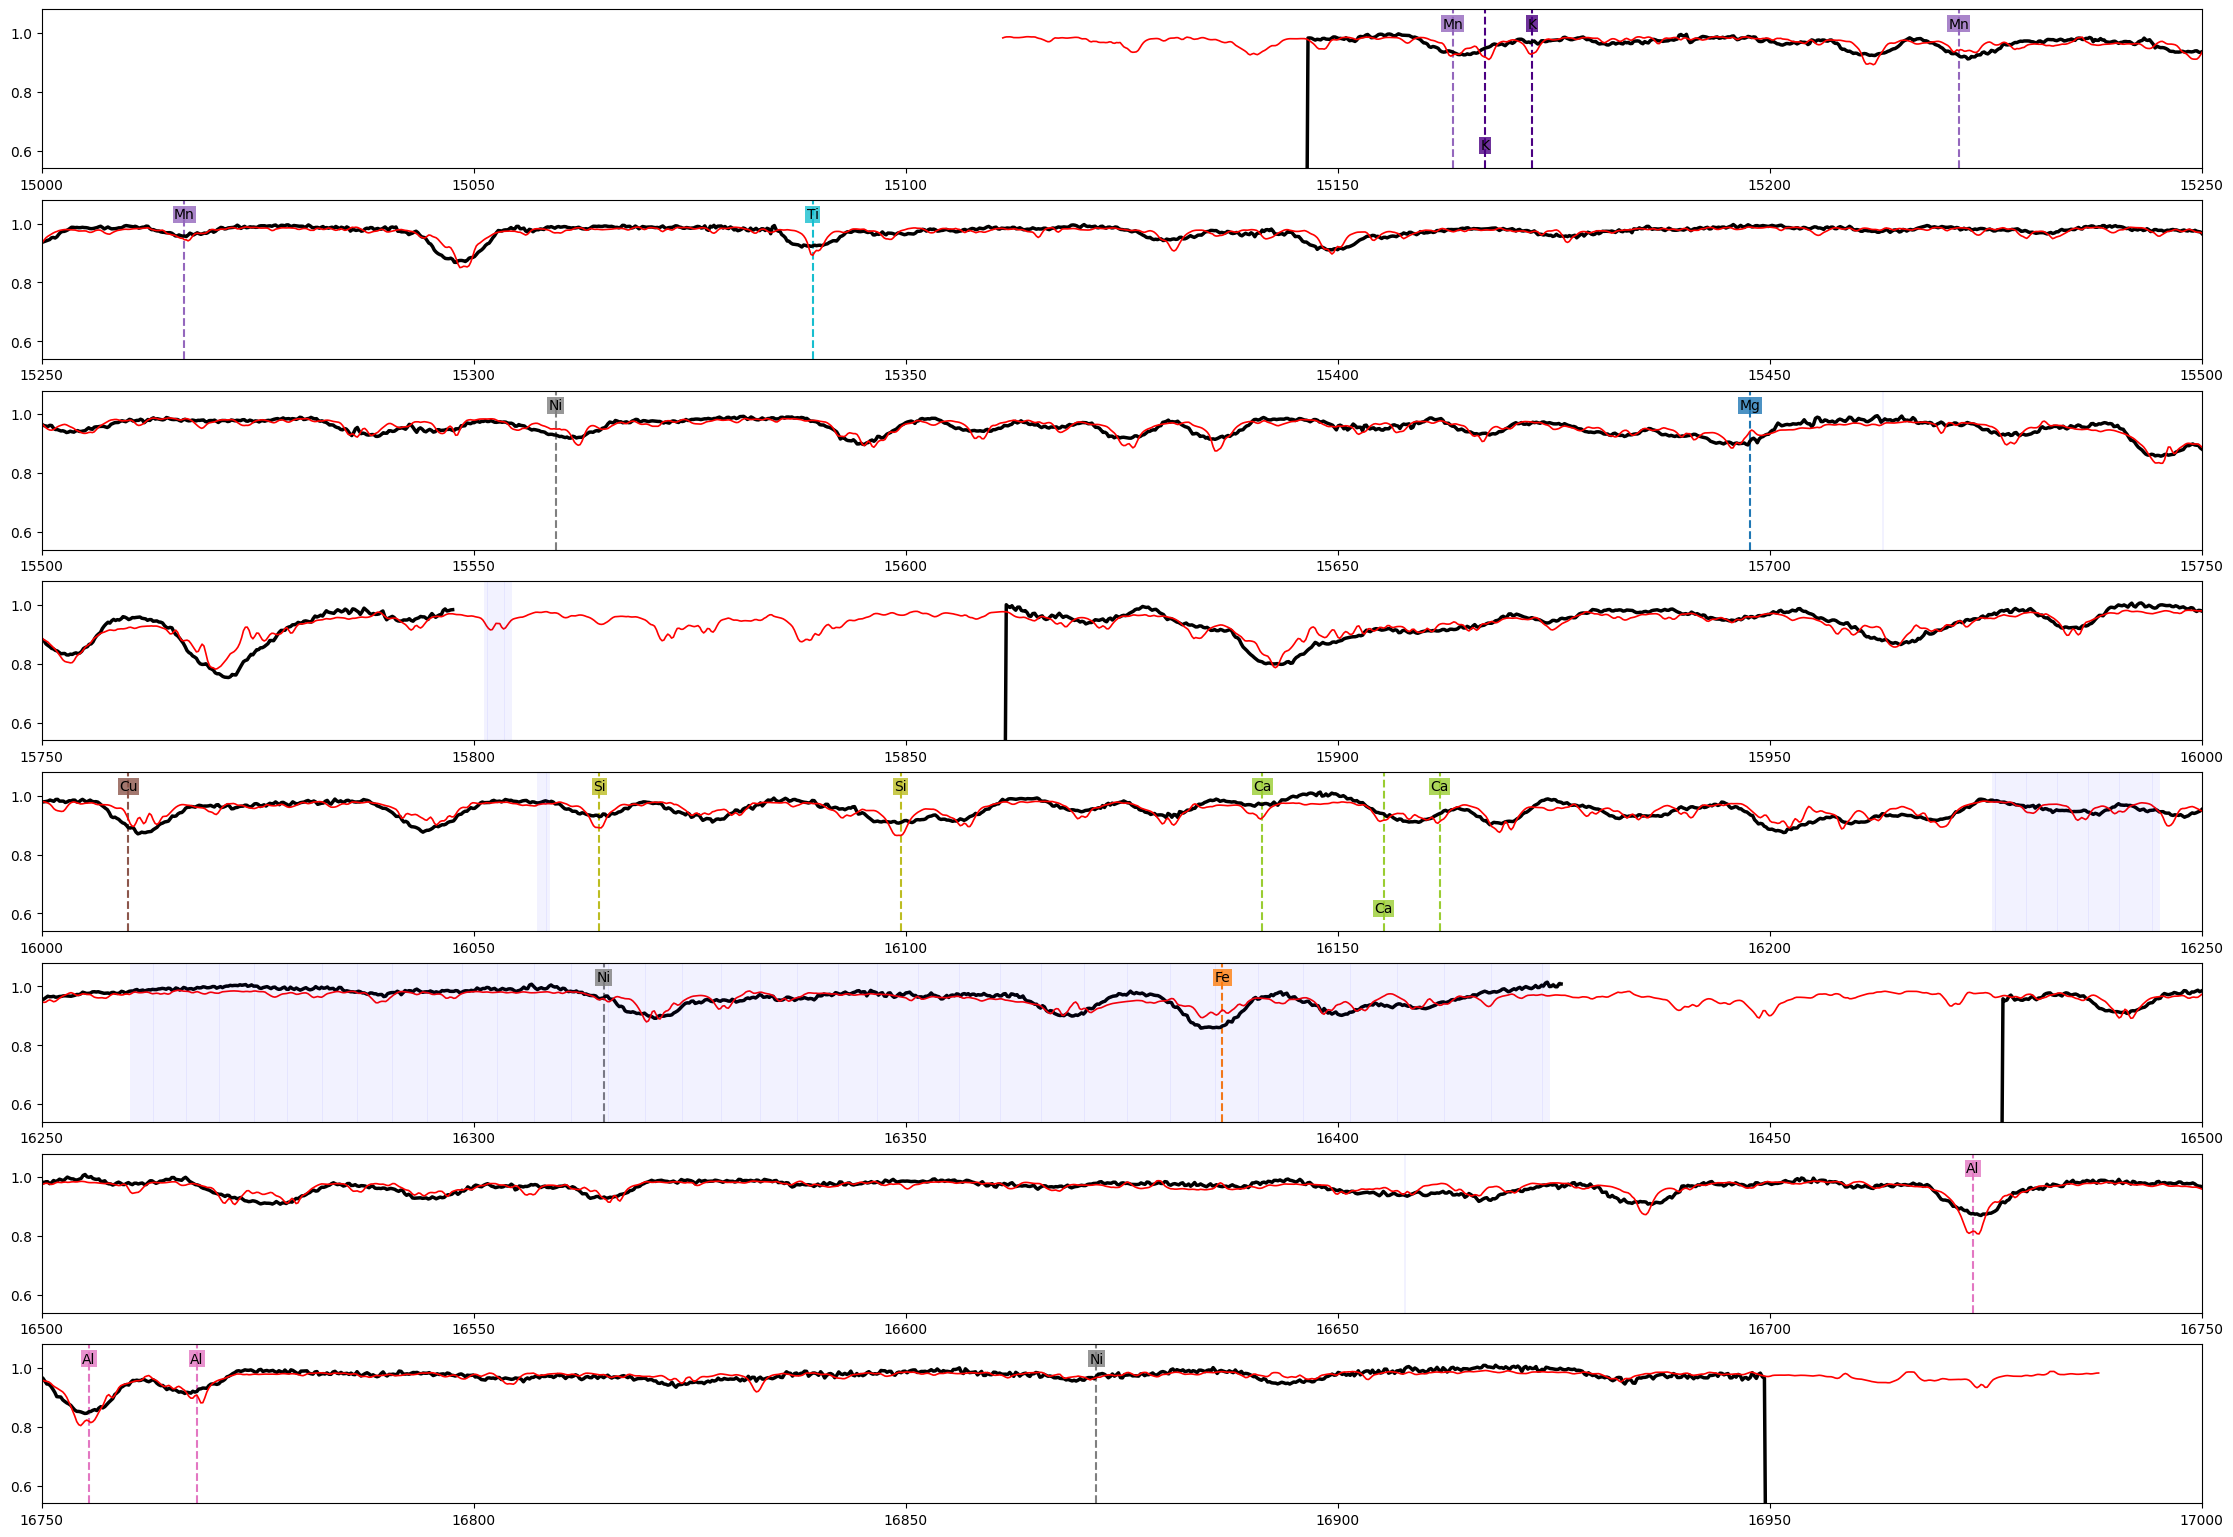

In [8]:
def plot_spectrum(wave,flux,errs,model,mask):
    # number of subplots
    dd=8
    f,a=plt.subplots(dd,figsize=(24,18))
    qqq=int(len(wave)/dd)
    # range of wavelengths to plot
    beg,end=15000,17000
    ran=end-beg


    # lines that contribute most strongly to elements in ASPCAP windows, from ASPCAP windows file
    # these are not exact, and were determined from where the windows weights peak, not from a linelist
    # they may not be accurate. but i put them there to guide the eye 
    multiwindows={
        'Mg':[15697.699],
        'Al':[16723.532,16755.446,16767.951],
        'Si':[16099.411,16064.529],
        'Ca':[16141.281,16155.336,16161.810],
        'Ti':[15339.246],
        'Mn':[15163.310,15266.518,15221.870],
        'Fe':[16386.643],
        'Ni':[16872.056,16315.035,15559.513],
        'Cu':[16010.025],
        'K':[15167.081,15172.530],
    }
 
    colors={'Mg': "tab:blue", 
            'Al': "tab:pink",
            'Si': "tab:olive",
            'Ca': "yellowgreen",
            'Ti': "tab:cyan",
            'Mn': "tab:purple",
            'Fe': "tab:orange",
            'Ni': "tab:gray", 
            'Cu': "tab:brown",
            'K': "indigo"}
    med = 0.9
    for k in range(dd):
        # set yscale of plot
        a[k].set_ylim(med*0.6,med*1.2)
        
        # plotting vertical lines for the elements in the ASPCAP windows  
        lineq=[]
        linee=[]
        for el in multiwindows:
            for line in multiwindows[el]:
                a[k].axvline(line,color=colors[el],linestyle='dashed')
                
                lineq.append(line)
                linee.append(el)
        
        zipped=zip(lineq,linee)
        szipped = sorted(zipped)
        lineq,linee=zip(*szipped)

        # some minor adjustments to the vertical placement of the labels to avoid overlap
        buff=8
        linev=[]
        for l in range(len(lineq)):
            line=lineq[l]
            el=linee[l]
            vert=med*1.13
            if np.any([np.abs(line-q)<buff for q in lineq if q!=line]):

                if len(linev)>0 and linev[-1]==vert:
                    vert=med*0.67
            linev.append(vert)

            q=a[k].annotate(el,(line,vert),color='k',horizontalalignment='center')
            q.set_bbox(dict(facecolor=colors[el], alpha=0.8, pad=1, edgecolor = 'None'))

    # now actually plotting the spectra
    for k in range(dd):
        a[k].plot(wave, flux, 'k-', lw=2.5)
        a[k].plot(wave, model, 'r-', lw=1.2)
        a[k].fill_between(wave, (flux+errs), (flux-errs), color='gray', alpha=0.4, edgecolor=None)

        a[k].set_xlim(beg+k*ran/dd,beg+(k+1)*ran/dd)
        a[k].ticklabel_format(style='plain', axis='x')
        a[k].vlines(wave[mask > 0], ymin=0, ymax=1.3, color='blue', lw=0.25, alpha=0.3)
    for el in multiwindows:
        a[-1].plot([],[],color=colors[el],linestyle='dashed',label=el)
 
    f.subplots_adjust(top=0.94,left=0.05,right=0.95)

    plt.show()
    return f

wave = mwmStar["wavelength"][0]
flux = mwmStar["flux"][0]/mwmStar["continuum"][0]
errs = 1/np.sqrt(mwmStar["ivar"][0])/mwmStar["continuum"][0]
mask = mwmStar["pixel_flags"][0] != 0
model = mwmStar["nmf_rectified_model_flux"][0]

f = plot_spectrum(wave,flux,errs,model,mask)

### About this notebook

This notebook was created to give an example of using the `sdss-access` tool, and illustrate how to use an APOGEE spectrum.

**Authors**: Adam Wheeler, John Donor, Pierre Thibodeaux

**Last Update**: 2026 March 04

If you use `astropy`  for published research, please cite the
authors. Follow this link for more information about citing `astropy`:

* [Citing `astropy`](https://www.astropy.org/acknowledging.html)

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.